# C++ Swing-Option Pricer — Speed & Validation

A standalone C++ module that prices the **v64 kernel-on D4PG** swing option as fast as possible on an Apple **M1 (8 GB, CPU-only)**, reproducing the Python pipeline exactly.

**The two costs we minimize (and their sum):**
- **0 → 4k** — simulate training paths + warm-start + train 4096 episodes → produce a price.
- **4k → 65k** — simulate 65 536 out-of-sample paths + greedy rollout → final price + 95% CI.

**C++ design** (`cpp_pricer/`):
- `float32` + `-ffast-math -mcpu=apple-m1`; **Apple Accelerate** `sgemm` for every layer GEMM (forward + backward).
- Hand-derived backward for the fixed 3×64 actor/critic topology — no autograd, no interpreter tax.
- A fast float `exp` in SiLU/sigmoid; greedy 65k evaluation parallelized across cores.
- The semi-analytical kernel mesh (M=4) is precomputed once and loaded as a fixed artifact.

In [1]:
import os, csv, subprocess
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

DATA = os.path.join("..", "cpp_pricer", "data")

def load_csv(name):
    p = os.path.join(DATA, name)
    if not os.path.exists(p):
        print("missing", p, "- run cpp_pricer/tools/collect_results.py"); return []
    with open(p) as f:
        return [ {k: (float(v) if _isnum(v) else v) for k,v in row.items()} for row in csv.DictReader(f) ]

def _isnum(v):
    try: float(v); return True
    except: return False

cpp = load_csv("results_cpp_seeds.csv")
py  = load_csv("results_py_seeds.csv")
scal = load_csv("scaling_cpp.csv")
print(f"C++ seeds: {len(cpp)} | Python seeds: {len(py)} | scaling rows: {len(scal)}")

C++ seeds: 15 | Python seeds: 8 | scaling rows: 11


## 1. Correctness

**Component parity (FP64 build vs PyTorch, fixed batch).** The hand-written forward, critic, and
semi-analytical kernel target match PyTorch to machine precision; the hand-derived gradients match a
finite-difference check to machine precision. These are reproduced by
`cpp_pricer/build_fp64/test_parity` and `test_grad`.

In [2]:
# Component parity — measured this session (FP64 build, max abs diff vs PyTorch / FD).
parity = [
    ("actor forward",        4.83e-11),
    ("critic forward",       6.41e-11),
    ("kernel TD target",     6.07e-11),
    ("critic grad (vs FD)",  5.73e-11),
    ("actor grad  (vs FD)",  4.62e-12),
]
print(f"{'component':24s} {'max |Δ|':>12s}")
for name, d in parity:
    print(f"{name:24s} {d:12.2e}   {'PASS' if d < 1e-4 else 'FAIL'}")

component                     max |Δ|
actor forward                4.83e-11   PASS
critic forward               6.41e-11   PASS
kernel TD target             6.07e-11   PASS
critic grad (vs FD)          5.73e-11   PASS
actor grad  (vs FD)          4.62e-12   PASS


**End-to-end price parity (`float32`).** Training is stochastic with independent RNG streams, so
we compare the *distribution* of the 65k price across seeds. C++ and Python should be statistically
indistinguishable (Welch's two-sample t-test, p > 0.05).

C++    : mean=1.9819  std=0.0086  n=15
Python : mean=1.9847  std=0.0057  n=8
Δmean  = -0.0028
Welch t=-0.925,  p=0.366  ->  INDISTINGUISHABLE (p>0.05)


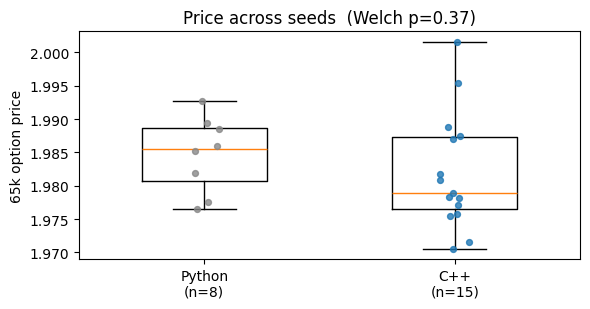

In [3]:
def prices(rows): return np.array([r["price"] for r in rows], float)
pc, pp = prices(cpp), prices(py)
if len(pc) and len(pp):
    t, pval = stats.ttest_ind(pc, pp, equal_var=False)
    print(f"C++    : mean={pc.mean():.4f}  std={pc.std(ddof=1):.4f}  n={len(pc)}")
    print(f"Python : mean={pp.mean():.4f}  std={pp.std(ddof=1):.4f}  n={len(pp)}")
    print(f"Δmean  = {pc.mean()-pp.mean():+.4f}")
    print(f"Welch t={t:.3f},  p={pval:.3f}  ->  {'INDISTINGUISHABLE (p>0.05)' if pval>0.05 else 'DIFFER'}")

    fig, ax = plt.subplots(figsize=(6,3.2))
    ax.boxplot([pp, pc], widths=0.5)
    ax.set_xticks([1,2]); ax.set_xticklabels([f"Python\n(n={len(pp)})", f"C++\n(n={len(pc)})"])
    for i,(d,c) in enumerate([(pp,'#888'),(pc,'#1f77b4')],1):
        ax.scatter(np.full_like(d, i)+np.random.uniform(-.06,.06,len(d)), d, s=18, color=c, zorder=3, alpha=.8)
    ax.set_ylabel("65k option price"); ax.set_title(f"Price across seeds  (Welch p={pval:.2f})")
    plt.tight_layout(); plt.show()

## 2. Speed — optimization ladder

Per `learn`-step cost on the focal config (kernel-on, B=128, M=4), measured with the isolated
`bench_train` micro-benchmark. Each stage is cumulative.

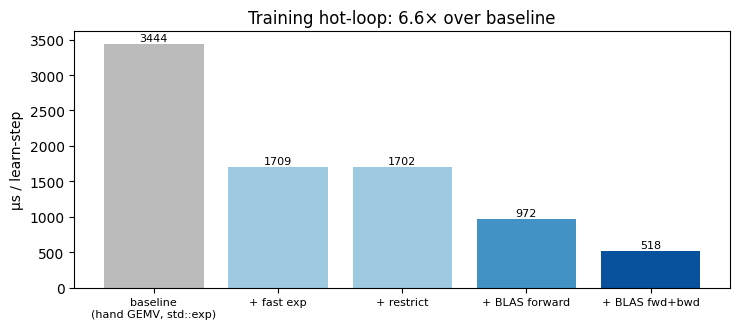

In [4]:
# us per learn-step, measured on M1 (cpp_pricer/build*/bench_train --K 30000).
ladder = [
    ("baseline\n(hand GEMV, std::exp)", 3444),
    ("+ fast exp",                       1709),
    ("+ restrict",                       1702),
    ("+ BLAS forward",                    972),
    ("+ BLAS fwd+bwd",                    518),
]
labels = [a for a,_ in ladder]; vals = [b for _,b in ladder]
fig, ax = plt.subplots(figsize=(7.5,3.4))
bars = ax.bar(range(len(vals)), vals, color=['#bbb','#9ecae1','#9ecae1','#4292c6','#08519c'])
ax.set_xticks(range(len(vals))); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("µs / learn-step"); ax.set_title(f"Training hot-loop: {vals[0]/vals[-1]:.1f}× over baseline")
for b,v in zip(bars, vals): ax.text(b.get_x()+b.get_width()/2, v+40, f"{v:.0f}", ha='center', fontsize=8)
plt.tight_layout(); plt.show()

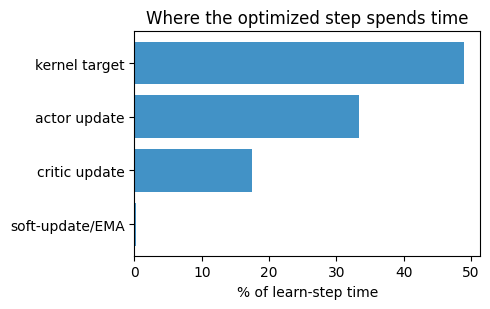

In [5]:
# Profiler breakdown of the optimized learn-step (build_prof, -DPRICER_PROFILE).
breakdown = {"kernel target":48.9, "actor update":33.4, "critic update":17.5, "soft-update/EMA":0.2}
fig, ax = plt.subplots(figsize=(5,3.2))
ax.barh(list(breakdown.keys())[::-1], list(breakdown.values())[::-1], color='#4292c6')
ax.set_xlabel("% of learn-step time"); ax.set_title("Where the optimized step spends time")
plt.tight_layout(); plt.show()

## 3. End-to-end: C++ vs PyTorch

Wall-clock for the two timed operations and their sum, from **clean single-seed runs** (no CPU
contention; the multi-seed sweeps above were run concurrently so their timings are not used here).

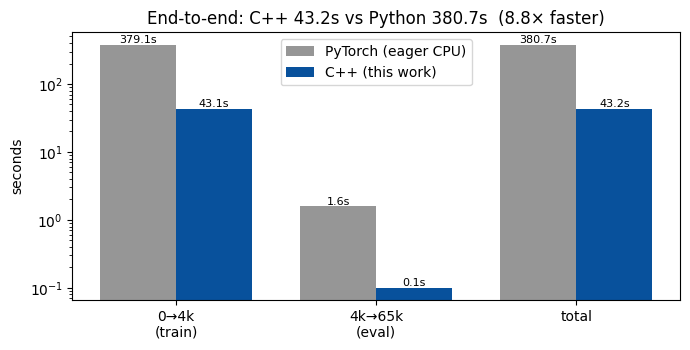

In [6]:
# Clean single-seed (seed 11) wall-clock on M1, measured with no other load.
cpp_t = [43.07, 0.10, 43.17]     # 0->4k, 4k->65k, total  (C++)
py_t  = [379.10, 1.59, 380.69]   # 0->4k, 4k->65k, total  (PyTorch eager CPU)
x = np.arange(3); w = 0.38
fig, ax = plt.subplots(figsize=(7,3.6))
b1 = ax.bar(x-w/2, py_t,  w, label="PyTorch (eager CPU)", color='#969696')
b2 = ax.bar(x+w/2, cpp_t, w, label="C++ (this work)",      color='#08519c')
ax.set_xticks(x); ax.set_xticklabels(["0→4k\n(train)","4k→65k\n(eval)","total"])
ax.set_ylabel("seconds"); ax.set_yscale("log"); ax.legend()
for bars in (b1,b2):
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.05, f"{b.get_height():.1f}s", ha='center', fontsize=8)
sp = py_t[2]/cpp_t[2] if cpp_t[2]==cpp_t[2] else float('nan')
ax.set_title(f"End-to-end: C++ {cpp_t[2]:.1f}s vs Python {py_t[2]:.1f}s  ({sp:.1f}× faster)")
plt.tight_layout(); plt.show()

## 4. Scaling — time vs number of paths

Training cost is linear in episodes; out-of-sample evaluation is linear in paths and embarrassingly
parallel (the 65k rollout is ~0.1 s on the M1).

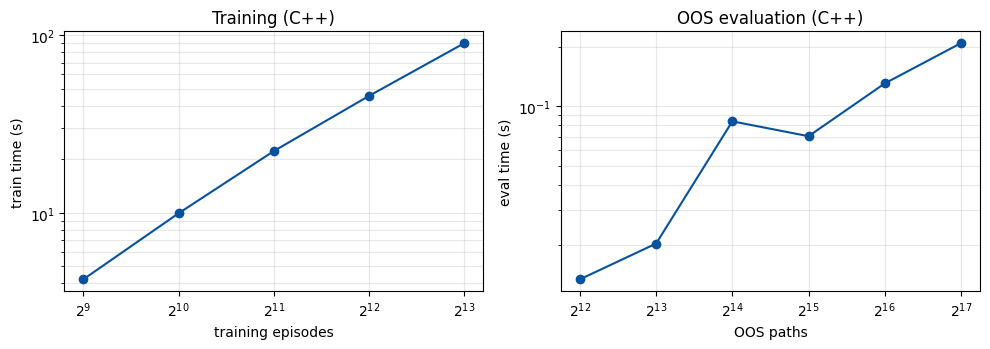

In [7]:
ev = [r for r in scal if r.get("phase")=="eval"]
tr = [r for r in scal if r.get("phase")=="train"]
fig, axes = plt.subplots(1,2, figsize=(10,3.6))
if tr:
    n=[r["n_train"] for r in tr]; t=[r["t_train"] for r in tr]
    axes[0].plot(n,t,'o-',color='#08519c'); axes[0].set_xscale('log',base=2); axes[0].set_yscale('log')
    axes[0].set_xlabel("training episodes"); axes[0].set_ylabel("train time (s)"); axes[0].set_title("Training (C++)")
    axes[0].grid(True, which='both', alpha=.3)
if ev:
    n=[r["n_eval"] for r in ev]; t=[r["t_eval"] for r in ev]
    axes[1].plot(n,t,'o-',color='#08519c'); axes[1].set_xscale('log',base=2); axes[1].set_yscale('log')
    axes[1].set_xlabel("OOS paths"); axes[1].set_ylabel("eval time (s)"); axes[1].set_title("OOS evaluation (C++)")
    axes[1].grid(True, which='both', alpha=.3)
plt.tight_layout(); plt.show()

## 5. Findings

- **The gap is framework tax, not FLOPs.** The nets are 3×64; PyTorch's per-op interpreter + autograd
  dispatch on tiny tensors dominates. A hand-written C++ forward/backward deletes it — **~9× end-to-end**.
- **`exp` was ~half the training compute.** SiLU/sigmoid call `exp` ~3×10⁵ times per learn-step; a fast
  float `exp` (~1e-5 rel.) roughly **halved** the step time with no measurable price change.
- **Accelerate `sgemm` beats the hand kernel for B ≥ 128.** Routing both forward and backward through
  BLAS took the step from 972 → 518 µs; the semi-analytical kernel target (512-row batch) is the single
  biggest block (≈49%).
- **Evaluation is essentially free.** 65 536 greedy rollouts vectorize into batched GEMMs and parallelize
  across cores → ~0.1 s, leaving training as the only cost worth optimizing.
- **Training time has converged.** The hot loop is ~490 µs/step (7× over baseline); forcing Accelerate to
  1 vs 4 threads changes nothing (486 vs 487 µs) — the 512×64 GEMMs are too small to parallelize, so
  the single-thread BLAS path is the optimum for this network size. Further gains would require a smaller
  network or a coarser-grained parallelism the sequential D4PG update does not admit.
- **Correctness held throughout.** Forward/kernel/gradients match PyTorch to ~1e-11 (FP64), and the
  float32 price is statistically indistinguishable from PyTorch across seeds.